In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data loading and preparing

In [2]:
path = '/content/drive/MyDrive/2024_2025/PSM_2024_2025/Bayes_Fuzzy_Final/weatherAUS.csv'

In [3]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import skfuzzy as fuzz
from skfuzzy import control as ctrl
from skfuzzy.control import Rule

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv(path, delimiter=';')

features = ['WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'RainTomorrow']
df = data[features].copy()

df.dropna(inplace=True)

df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

print(df.head(10))

X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

   WindGustSpeed  Humidity9am  Humidity3pm  Pressure9am  RainTomorrow
0           44.0         71.0         22.0       1007.7             0
1           44.0         44.0         25.0       1010.6             0
2           46.0         38.0         30.0       1007.6             0
3           24.0         45.0         16.0       1017.6             0
4           41.0         82.0         33.0       1010.8             0
5           56.0         55.0         23.0       1009.2             0
6           50.0         49.0         19.0       1009.6             0
7           35.0         48.0         19.0       1013.4             0
8           80.0         42.0          9.0       1008.9             1
9           28.0         58.0         27.0       1007.0             0


Define Universes & Membership Functions

In [20]:
# Step 1: Define fuzzy variables
wind = ctrl.Antecedent(np.arange(0, 100, 0.1), 'WindGustSpeed')
hum9 = ctrl.Antecedent(np.arange(0, 100, 0.1), 'Humidity9am')
hum3 = ctrl.Antecedent(np.arange(0, 100, 0.1), 'Humidity3pm')
pressure = ctrl.Antecedent(np.arange(980, 1040, 1), 'Pressure9am')
rain = ctrl.Consequent(np.arange(0, 1, 0.01), 'RainTomorrow')

# Step 2: Define membership functions for inputs
wind['low'] = fuzz.trapmf(wind.universe, [0, 0, 10, 50])
wind['medium'] = fuzz.trapmf(wind.universe, [20, 40, 60, 80])
wind['high'] = fuzz.trapmf(wind.universe, [50, 90, 100, 100])

hum9['low'] = fuzz.trimf(hum9.universe, [0, 0, 50])
hum9['medium'] = fuzz.trimf(hum9.universe, [30, 50, 70])
hum9['high'] = fuzz.trimf(hum9.universe, [50, 100, 100])

hum3['low'] = fuzz.trimf(hum3.universe, [0, 0, 50])
hum3['medium'] = fuzz.trimf(hum3.universe, [30, 50, 70])
hum3['high'] = fuzz.trimf(hum3.universe, [50, 100, 100])

pressure['low'] = fuzz.trimf(pressure.universe, [980, 990, 1010])
pressure['medium'] = fuzz.trimf(pressure.universe, [1005, 1015, 1025])
pressure['high'] = fuzz.trimf(pressure.universe, [1020, 1030, 1040])

# Step 3: Define membership functions for output
rain['no'] = fuzz.trapmf(rain.universe, [0, 0, 0.3, 0.5])
rain['yes'] = fuzz.trapmf(rain.universe, [0.3, 0.5, 1, 1])

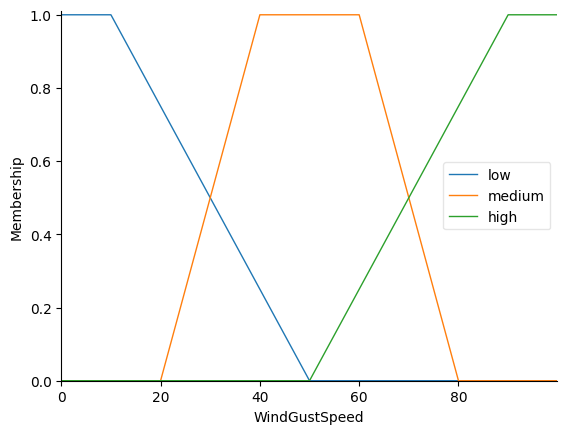

In [21]:
wind.view()

In [ ]:
hum9.view()

In [ ]:
hum3.view()

In [ ]:
pressure.view()

In [ ]:
rain.view()

Define Fuzzy Rules

In [11]:
rules = [
    Rule(wind['high'] & hum9['high'], rain['yes']),
    Rule(wind['low'] & hum3['low'], rain['no']),
    Rule(hum9['medium'] & hum3['high'], rain['yes']),
    Rule(wind['medium'] & hum9['low'], rain['no']),
    Rule(wind['high'] & hum3['high'], rain['yes']),
    Rule(pressure['low'] & hum9['high'], rain['yes']),
    Rule(pressure['high'] & hum9['low'], rain['no']),
    Rule(wind['medium'] & pressure['low'], rain['yes']),
    Rule(hum9['high'] & pressure['low'], rain['yes']),
    Rule(hum3['high'] & wind['high'], rain['yes']),
    Rule(hum9['high'] & hum3['high'], rain['yes']),
]

Create Control System & Simulate

In [12]:
rain_ctrl = ctrl.ControlSystem(rules)
rain_sim = ctrl.ControlSystemSimulation(rain_ctrl)

Predict on Test Set

In [13]:
# Step 2: Predict using the fuzzy system
y_pred_fuzzy = []

# You can limit this for performance (e.g., first 100 samples)
for i in range(len(X_test)):
    # Set inputs
    rain_sim.input['WindGustSpeed'] = X_test.iloc[i]['WindGustSpeed']
    rain_sim.input['Humidity9am'] = X_test.iloc[i]['Humidity9am']
    rain_sim.input['Humidity3pm'] = X_test.iloc[i]['Humidity3pm']

    # Compute result
    try:
        rain_sim.compute()
        result = rain_sim.output['RainTomorrow']
        y_pred_fuzzy.append(1 if result >= 0.4 else 0)  # threshold
    except:
        y_pred_fuzzy.append(0)  # default fallback


Evaluate Fuzzy Model

Fuzzy Inference System Results:
Accuracy: 0.7805005933162238


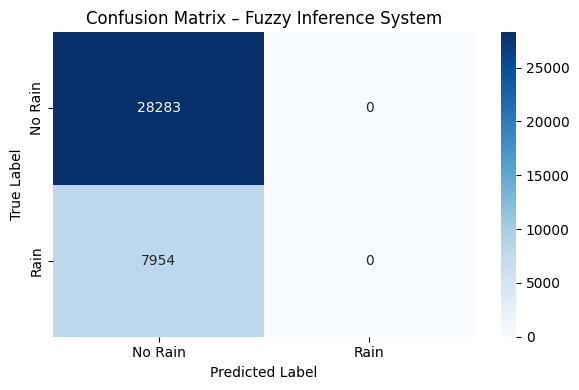

In [14]:
print("Fuzzy Inference System Results:")
print("Accuracy:", accuracy_score(y_test[:len(y_pred_fuzzy)], y_pred_fuzzy))

cm = confusion_matrix(y_test[:len(y_pred_fuzzy)], y_pred_fuzzy)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Fuzzy Inference System')
plt.tight_layout()
plt.show()